  LAJI   pohj_etrs     ita_etrs  VAKAV_A    VV
0   JK  6675786.73  25501661.91        1  2022
1   JK  6674533.32  25502790.94        2  2022
2   JK  6679536.47  25506837.81        2  2022
3   JK  6675297.68  25498807.13        2  2022
4   JK  6674924.21  25495525.13        2  2022


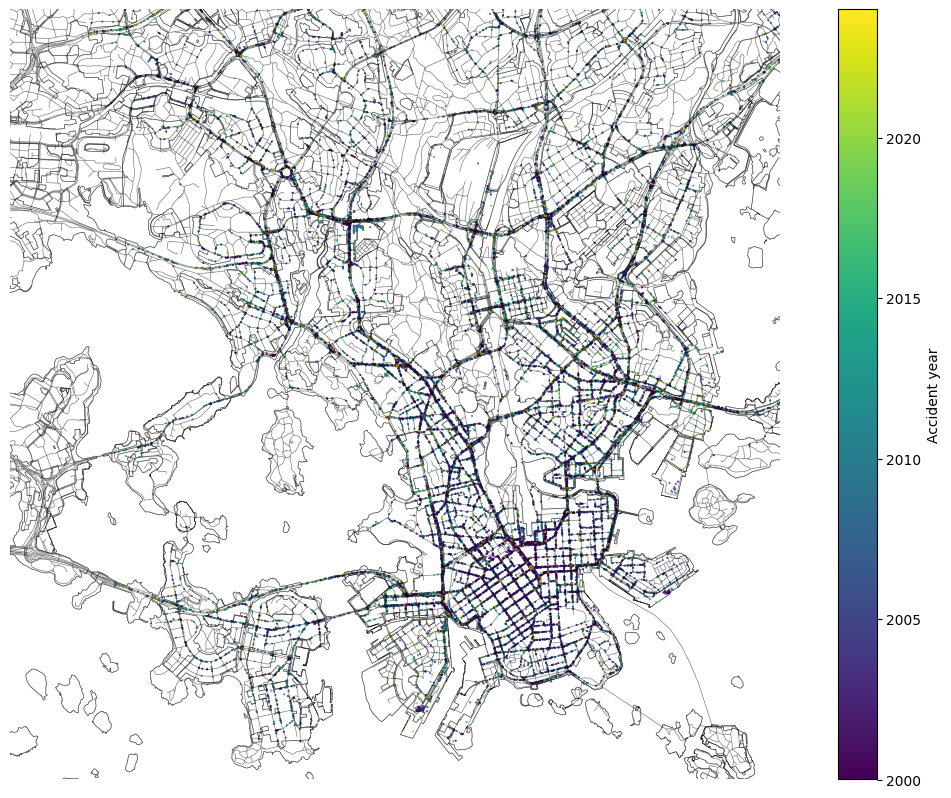

In [35]:
import pandas as pd
import geopandas as gp
import matplotlib.pyplot as plt

df = pd.read_csv("liikenneonnettomuudet_Helsingissa.csv", sep=";")
print(df.head())

gdf = gp.GeoDataFrame(
    df,
    geometry=gp.points_from_xy(
        df.ita_etrs, df.pohj_etrs
    ),
    crs="EPSG:3879"
)

background = gp.read_file("seutukartta_2024/Seutukartta_tausta.shp")
roads = gp.read_file("seutukartta_2024/Seutukartta_tiesto.shp")

fig, ax = plt.subplots(figsize=(15, 10))
ax.set_aspect("equal")

background.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5, alpha=0.5)
roads.plot(ax=ax, color='black', edgecolor='white', linewidth=0.5, alpha=0.5)

gdf.plot(
    ax=ax, 
    column='VV',
    legend=True,
    legend_kwds={
        "label": "Accident year"
    },
    markersize=0.2
)

ax.set_ylim([6.67*1e6, 6.68*1e6])
ax.set_xlim([2.549*1e7, 2.550*1e7])
ax.set_axis_off()

plt.show()